Đang tải dữ liệu cho VHM...
Lỗi request: 404


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def crawl_cophieu68(symbol, num_pages=1):
    base_url = "https://www.cophieu68.vn/quote/history.php"
    all_data = []

    # Giả lập browser
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    # Lặp qua từng trang (cP = current Page)
    for page in range(1, num_pages + 1):
        print(f"Đang tải trang {page} cho mã {symbol}...")
        
        # Tạo params: id=vhm, cP=1, 2, 3...
        params = {
            'id': symbol,
            'cP': page
        }

        try:
            response = requests.get(base_url, params=params, headers=headers)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')
                
                # 1. Tìm bảng bằng ID cực kỳ chính xác: id="history"
                table = soup.find('table', id='history')
                
                if not table:
                    print(f"Không tìm thấy bảng dữ liệu ở trang {page}")
                    continue

                # 2. Lấy tất cả các dòng (tr)
                rows = table.find_all('tr')

                for row in rows:
                    # Bỏ qua dòng tiêu đề (có class là tr_header)
                    if 'tr_header' in row.get('class', []):
                        continue
                        
                    cols = row.find_all('td')
                    
                    # Kiểm tra độ dài để tránh dòng trống hoặc dòng quảng cáo
                    if len(cols) < 5:
                        continue

                    # 3. Trích xuất dữ liệu (Mapping theo HTML bạn cung cấp)
                    # Cột 0: Ngày
                    date_str = cols[0].text.strip()
                    
                    # Cột 1: Giá khớp (Nằm trong thẻ strong: <div><strong>51.50</strong></div>)
                    # .text sẽ lấy hết text bên trong các thẻ con nên vẫn lấy được 51.50
                    close_price = cols[1].text.strip()
                    
                    # Cột 2: Khối lượng (12,918,800 -> cần xóa dấu phẩy)
                    volume = cols[2].text.strip().replace(',', '')
                    
                    # Cột 3: Mở cửa
                    open_price = cols[3].text.strip()
                    
                    # Cột 4: Cao nhất
                    high_price = cols[4].text.strip()
                    
                    # Cột 5: Thấp nhất
                    low_price = cols[5].text.strip()

                    all_data.append({
                        'Ngay': date_str,
                        'Dong_cua': close_price,
                        'Mo_cua': open_price,
                        'Cao_nhat': high_price,
                        'Thap_nhat': low_price,
                        'Khoi_luong': volume
                    })
            else:
                print(f"Lỗi tải trang {page}: {response.status_code}")

            # Nên nghỉ 1 chút để không spam server họ
            time.sleep(1)

        except Exception as e:
            print(f"Lỗi: {e}")

    # 4. Trả về DataFrame
    df = pd.DataFrame(all_data)
    return df

# --- CHẠY THỬ ---
# Lấy thử 3 trang dữ liệu của VHM (tương ứng link bạn đưa là page 3)
df_vhm = crawl_cophieu68('vhm', num_pages=3)

if not df_vhm.empty:
    print("\n--- KẾT QUẢ ---")
    print(df_vhm.head())
    print(f"\nTổng số dòng lấy được: {len(df_vhm)}")
    
    # Lưu ra Excel
    df_vhm.to_excel("vhm_cophieu68.xlsx", index=False)

Đang tải trang 1 cho mã vhm...
Đang tải trang 2 cho mã vhm...
Đang tải trang 3 cho mã vhm...

--- KẾT QUẢ ---
         Ngay Dong_cua  Mo_cua Cao_nhat Thap_nhat Khoi_luong
0  09/01/2026      140  138.60   142.80    132.60    9789300
1  08/01/2026   139.10  150.30   150.90    139.10   15234400
2  07/01/2026   149.50     150   150.90       141    9511500
3  06/01/2026   141.80  138.50   141.80    136.50    8459900
4  05/01/2026   132.60  126.80   132.60    125.20   10136200

Tổng số dòng lấy được: 300


In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime, timedelta

def crawl_cophieu68_full_history(symbol, max_years=15):
    base_url = "https://www.cophieu68.vn/quote/history.php"
    all_data = []
    
    # Tính ngày giới hạn (15 năm trước từ hôm nay)
    limit_date = datetime.now() - timedelta(days=365 * max_years)
    print(f"--- Bắt đầu crawl {symbol}. Giới hạn dữ liệu đến: {limit_date.strftime('%d/%m/%Y')} ---")

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    page = 1
    stop_crawling = False # Cờ để báo hiệu dừng vòng lặp

    while not stop_crawling:
        print(f"Đang tải trang {page}...", end="\r") # In đè dòng để đỡ rối mắt
        
        params = {
            'id': symbol,
            'cP': page
        }

        try:
            response = requests.get(base_url, params=params, headers=headers, timeout=10)
            
            if response.status_code != 200:
                print(f"\nLỗi kết nối ở trang {page}: {response.status_code}")
                break

            soup = BeautifulSoup(response.content, 'html.parser')
            table = soup.find('table', id='history')
            
            # ĐIỀU KIỆN DỪNG 1: Không tìm thấy bảng -> Hết trang hoặc lỗi
            if not table:
                print(f"\nKhông tìm thấy bảng dữ liệu ở trang {page}. Dừng lại.")
                break

            rows = table.find_all('tr')
            
            # Biến đếm số dòng dữ liệu hợp lệ tìm được trong trang này
            valid_rows_in_page = 0 

            for row in rows:
                if 'tr_header' in row.get('class', []):
                    continue
                
                cols = row.find_all('td')
                if len(cols) < 5:
                    continue

                # Lấy ngày để kiểm tra điều kiện dừng thời gian
                date_str = cols[0].text.strip()
                
                try:
                    # Convert chuỗi ngày sang datetime object
                    current_date_obj = datetime.strptime(date_str, '%d/%m/%Y')
                    
                    # ĐIỀU KIỆN DỪNG 2: Dữ liệu quá cũ (vượt quá 15 năm)
                    if current_date_obj < limit_date:
                        print(f"\nĐã chạm mốc thời gian giới hạn ({date_str}). Dừng lại.")
                        stop_crawling = True
                        break # Break khỏi vòng for row
                    
                    # Nếu chưa quá hạn thì lấy dữ liệu tiếp
                    close_price = cols[1].text.strip()
                    volume = cols[2].text.strip().replace(',', '')
                    open_price = cols[3].text.strip()
                    high_price = cols[4].text.strip()
                    low_price = cols[5].text.strip()

                    all_data.append({
                        'Ngay': current_date_obj, # Lưu dạng datetime để sort sau này nếu cần
                        'Dong_cua': close_price,
                        'Mo_cua': open_price,
                        'Cao_nhat': high_price,
                        'Thap_nhat': low_price,
                        'Khoi_luong': volume
                    })
                    valid_rows_in_page += 1

                except ValueError:
                    continue # Bỏ qua nếu lỗi format ngày

            # ĐIỀU KIỆN DỪNG 3: Trang này không có dòng dữ liệu hợp lệ nào (Trang trống cuối cùng)
            if valid_rows_in_page == 0 and not stop_crawling:
                print(f"\nTrang {page} không có dữ liệu. Đã hết lịch sử.")
                break

            # Tăng số trang lên để lấy tiếp
            page += 1
            
            # Sleep nhẹ để tránh bị chặn IP nếu request quá nhanh
            # time.sleep(0.5) 

        except Exception as e:
            print(f"\nCó lỗi xảy ra: {e}")
            break

    # --- KẾT THÚC CRAWL ---
    df = pd.DataFrame(all_data)
    
    # Format lại cột ngày ra string cho đẹp khi in/lưu (tùy chọn)
    # df['Ngay'] = df['Ngay'].dt.strftime('%d/%m/%Y')
    
    return df

# --- CHẠY THỬ VỚI VHM ---
# VHM mới lên sàn khoảng 2018, nên nó sẽ chạy đến trang cuối cùng rồi dừng (chưa tới 15 năm)
symbol_input = 'VHM'
df_result = crawl_cophieu68_full_history(symbol_input, max_years=15)

if not df_result.empty:
    print(f"\n\nTổng cộng: {len(df_result)} phiên giao dịch.")
    print("5 dòng dữ liệu cũ nhất:")
    print(df_result.tail()) # In phần đuôi để xem ngày cũ nhất lấy được là bao nhiêu
    
    # Lưu ra Excel
    filename = f"{symbol_input}_full_history.xlsx"
    df_result.to_excel(filename, index=False)
    print(f"Đã lưu file: {filename}")
else:
    print("Không lấy được dữ liệu nào.")

--- Bắt đầu crawl VHM. Giới hạn dữ liệu đến: 14/01/2011 ---
Đang tải trang 21...
Trang 21 không có dữ liệu. Đã hết lịch sử.


Tổng cộng: 1915 phiên giao dịch.
5 dòng dữ liệu cũ nhất:
           Ngay Dong_cua Mo_cua Cao_nhat Thap_nhat Khoi_luong
1910 2018-05-23    64.25  68.85    68.85     64.08    4839580
1911 2018-05-22    68.85  64.37    68.85     68.85         20
1912 2018-05-21    64.37  64.37    64.37     64.37          0
1913 2018-05-18    64.37  64.37    64.37     64.37          0
1914 2018-05-17    64.37  64.37    64.37     64.37      18000
Đã lưu file: VHM_full_history.xlsx


In [7]:
! pip install mplfinance


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Đang đọc file VHM_full_history.xlsx...
Đang vẽ biểu đồ...


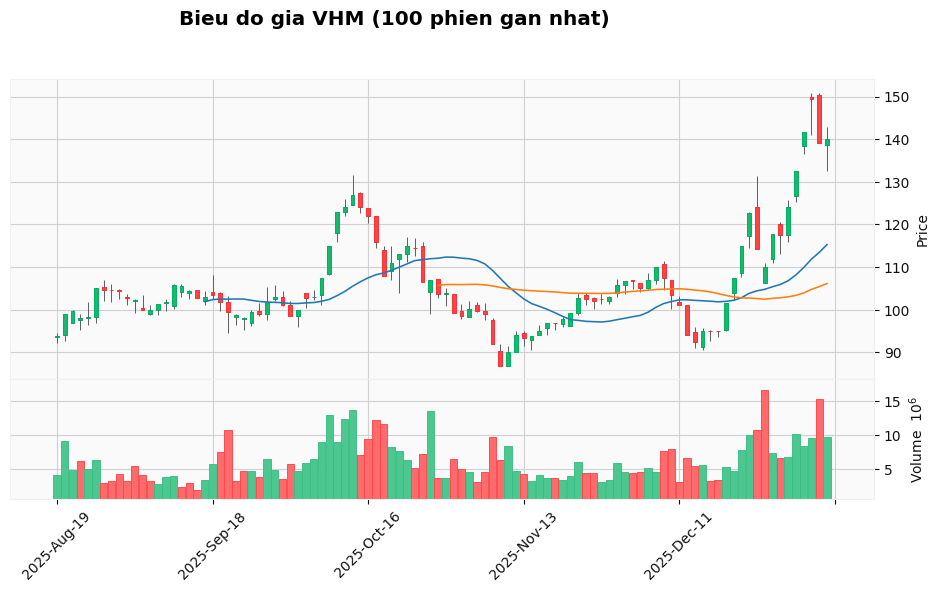

In [8]:
import pandas as pd
import mplfinance as mpf

# 1. Đọc file Excel vừa crawl được
file_path = 'VHM_full_history.xlsx'
print(f"Đang đọc file {file_path}...")
df = pd.read_excel(file_path)

# 2. Xử lý dữ liệu chuẩn format cho mplfinance
# Thư viện này yêu cầu Index phải là Ngày tháng (DatetimeIndex)
df['Ngay'] = pd.to_datetime(df['Ngay'])
df.set_index('Ngay', inplace=True)

# Sắp xếp lại thời gian từ cũ đến mới (quan trọng để vẽ biểu đồ đúng chiều)
df.sort_index(ascending=True, inplace=True)

# Đổi tên cột sang tiếng Anh theo chuẩn của thư viện: Open, High, Low, Close, Volume
df.rename(columns={
    'Mo_cua': 'Open',
    'Cao_nhat': 'High',
    'Thap_nhat': 'Low',
    'Dong_cua': 'Close',
    'Khoi_luong': 'Volume'
}, inplace=True)

# Chắc chắn dữ liệu là số (float), ép kiểu để tránh lỗi string
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Vẽ biểu đồ
# Lấy 100 phiên gần nhất để vẽ cho rõ (vẽ cả 1900 phiên sẽ bị ríu mắt)
df_recent = df.tail(100)

print("Đang vẽ biểu đồ...")

# style='yahoo': Style màu xanh/đỏ quen thuộc
# type='candle': Biểu đồ nến
# volume=True: Vẽ thêm cột khối lượng bên dưới
# mav=(20, 50): Vẽ thêm đường trung bình động MA20 và MA50
mpf.plot(df_recent, 
         type='candle', 
         style='yahoo', 
         volume=True, 
         title='Bieu do gia VHM (100 phien gan nhat)',
         mav=(20, 50), 
         figsize=(12, 6))